# Module 02: Calculus and Multivariable Calculus for Machine Learning

---

## 🔗 Building on Module 01

**Where this comes from:** Course 01 (AIAT 111) — Unit 3, lesson 04 "Gradient Descent and Loss Functions" already had you hand-code MSE, hand-code its gradient, and sweep the learning rate until the loss stopped falling — you made gradient descent work without ever being told what a gradient *is*. Module 02 supplies that missing definition.

**Welcome back!** In Module 01, you learned about vectors, matrices, and linear transformations. Now we'll use those concepts:

- **Vectors from Module 01** → **Gradient vectors** (this module)
- **Matrix operations from Module 01** → **Jacobian matrices** for multivariable functions
- **Linear transformations** → **How data flows** through neural networks

> 💡 **Connection**: When we compute gradients, we're working with vectors and matrices you learned in Module 01!

**What's Next**: After this module, you'll use gradients in Module 03 for optimization algorithms.

---

## Learning Objectives

In this module, you will learn:
- Derivatives and their applications in machine learning
- Gradients and partial derivatives for multivariable functions
- The chain rule and its role in backpropagation
- How to compute gradients in Python using NumPy and automatic differentiation
- How calculus enables optimization in ML algorithms
- Understanding loss functions and their derivatives

---


---

## 📌 Real case: four pages in *Nature*, 1986

In October 1986 David Rumelhart, Geoffrey Hinton and Ronald Williams published four pages in *Nature*
called **"Learning representations by back-propagating errors."** The mathematics was not new — it is the
chain rule, and Seppo Linnainmaa had published the general reverse-mode procedure in 1970. What the paper
showed was that running the chain rule backwards through a network's layers made its *hidden* units invent
useful internal representations nobody had specified. That result turned neural networks from a curiosity
into a research programme, and every `loss.backward()` in every framework you will ever use is the same
idea.

**What goes wrong without this.** Suppose you tried to improve a model by nudging each parameter and
keeping the changes that helped. AlexNet, the network that won ImageNet in 2012, has **60 million
parameters** and its forward pass costs about 1.43 GFLOPs (≈0.7 billion multiply–adds, counted as two
operations each). Estimating one gradient that way needs 60 million forward passes ≈ 8.6 × 10¹⁶
floating-point operations — about **15 hours on one of the GTX 580 GPUs that paper used, for a single step
of training**, and that is the *optimistic* figure: it assumes the card sustains its theoretical peak of
1.58 TFLOP/s and never stalls. Calculus gets you all 60 million partial derivatives
for roughly the cost of two forward passes. That gap is not an optimisation. It is the difference between
deep learning existing and not existing.


# Part 1: WHY

## Understanding the Motivation

### Why does Calculus matter for Machine Learning?

Calculus is essential for training machine learning models. Here's why:

- **Optimization**: ML models are trained by minimizing loss functions using derivatives
- **Gradients**: Gradients tell us which direction to adjust parameters to reduce error
- **Backpropagation**: Neural networks use the chain rule to compute gradients through layers
- **Learning Rate**: Understanding derivatives helps tune learning rates effectively
- **Convergence**: Calculus helps understand when and how models converge to optimal solutions

### Real-World Applications

- **Neural Network Training**: Backpropagation relies entirely on calculus
- **Gradient Descent**: The most fundamental optimization algorithm in ML
- **Loss Function Minimization**: All supervised learning uses derivatives
- **Hyperparameter Tuning**: Understanding gradients helps optimize hyperparameters
- **Feature Engineering**: Derivatives help understand feature importance


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Example: Why Calculus matters in ML
import numpy as np
import matplotlib.pyplot as plt


### 🧪 The comparison that decides whether deep learning is possible

The case above claims that estimating a gradient by nudging parameters one at a time costs 60 million
forward passes for AlexNet, while calculus gets the same vector for about the cost of two. That is an
arithmetic claim, so let us do the arithmetic. Baseline: finite differences. Change one thing: reverse-mode
automatic differentiation. Measure: forward passes per gradient, and wall-clock time on real hardware.

In [2]:
# Comparative experiment: cost of one gradient, two ways, as the model grows.
# Reverse-mode automatic differentiation (what backpropagation is) computes ALL partial
# derivatives in a single backward sweep whose cost is a small multiple of one forward pass.
# Finite differences need at least one extra forward pass PER PARAMETER.

ALEXNET_FLOPS_PER_FORWARD = 1.43e9      # AlexNet, ~1.43 GFLOPs per forward pass
GTX580_FLOPS_PER_SECOND   = 1.581e12    # one NVIDIA GTX 580, float32 peak (the 2012 paper used two)

print("Cost of ONE gradient step, for a model with p parameters")
print("=" * 78)
print(f"{'parameters p':>14} {'finite diff (passes)':>22} {'reverse mode (passes)':>23} {'speed-up':>12}")
print("-" * 78)
for p in [1, 10, 1_000, 1_000_000, 60_000_000]:
    fd_passes = p + 1        # one baseline evaluation plus one per parameter
    ad_passes = 2            # forward pass plus a backward sweep of comparable cost
    print(f"{p:>14,} {fd_passes:>22,} {ad_passes:>23,} {fd_passes / ad_passes:>11,.0f}x")

print()
p = 60_000_000               # AlexNet
for label, passes in [("finite differences", p + 1), ("reverse mode (backprop)", 2)]:
    flops = passes * ALEXNET_FLOPS_PER_FORWARD
    seconds = flops / GTX580_FLOPS_PER_SECOND
    print(f"AlexNet, one gradient by {label:<24}: {flops:.3g} FLOPs -> {seconds / 3600:>10.2f} hours"
          if seconds > 3600 else
          f"AlexNet, one gradient by {label:<24}: {flops:.3g} FLOPs -> {seconds:>10.4f} seconds")

print()
print("Conclusion the numbers support: both methods return the same gradient vector. One of them")
print("makes training a 60-million-parameter network take hours PER STEP on 2012 hardware; the")
print("other makes it take a fraction of a second. Deep learning is not possible without the")
print("second column, and the second column is just the chain rule, applied backwards.")

Cost of ONE gradient step, for a model with p parameters
  parameters p   finite diff (passes)   reverse mode (passes)     speed-up
------------------------------------------------------------------------------
             1                      2                       2           1x
            10                     11                       2           6x
         1,000                  1,001                       2         500x
     1,000,000              1,000,001                       2     500,000x
    60,000,000             60,000,001                       2  30,000,000x

AlexNet, one gradient by finite differences      : 8.58e+16 FLOPs ->      15.07 hours
AlexNet, one gradient by reverse mode (backprop) : 2.86e+09 FLOPs ->     0.0018 seconds

Conclusion the numbers support: both methods return the same gradient vector. One of them
makes training a 60-million-parameter network take hours PER STEP on 2012 hardware; the
other makes it take a fraction of a second. Deep learning is

---

# Part 2: HOW

## Implementation and Practical Application

### How Calculus Works in Machine Learning

Let's understand **HOW** calculus operations work and **WHY** each is essential:

#### 1. **WHY Derivatives?**
- **WHY**: Tell us the direction to minimize loss (which way to adjust parameters)
- **HOW**: Derivative = rate of change = slope of the function
  - Positive derivative → function increasing → move left
  - Negative derivative → function decreasing → move right
  - Zero derivative → at minimum/maximum

#### 2. **WHY Gradients?**
- **WHY**: ML models have many parameters - need direction for each
- **HOW**: Gradient = vector of partial derivatives
  - Each element = how loss changes with respect to one parameter
  - Points in direction of steepest increase
  - Negative gradient = direction of steepest decrease (what we want!)

#### 3. **WHY Chain Rule?**
- **WHY**: Neural networks have multiple layers - need to compute gradients through all layers
- **HOW**: Chain rule allows us to:
  - Compute gradient of output w.r.t. input
  - Multiply gradients through each layer
  - This is **backpropagation**!

#### 4. **WHY Gradient Descent?**
- **WHY**: Find optimal parameters that minimize loss
- **HOW**: Iteratively update parameters:
  1. Compute gradient (direction of steepest increase)
  2. Move in opposite direction (steepest decrease)
  3. Repeat until convergence

### Step-by-Step: Working with Calculus in Python for ML

**Step-by-Step Guide to Working with Calculus in Python for ML:**

Here's how to apply calculus concepts in practice:

1. **Derivatives**: Computing derivatives of functions
2. **Gradients**: Understanding and computing gradients for multivariable functions
3. **Partial Derivatives**: Working with functions of multiple variables
4. **Chain Rule**: Understanding and applying the chain rule
5. **Gradient Descent**: Implementing gradient descent for optimization
6. **Automatic Differentiation**: Using libraries for automatic gradient computation

### Key Concepts to Cover:

- Single-variable derivatives
- Multivariable functions and partial derivatives
- Gradient vectors
- The chain rule and backpropagation
- Gradient descent algorithm
- Learning rate and convergence

Example: Basic Calculus Operations in Python for ML
This shows HOW each calculus concept works and WHY it's used



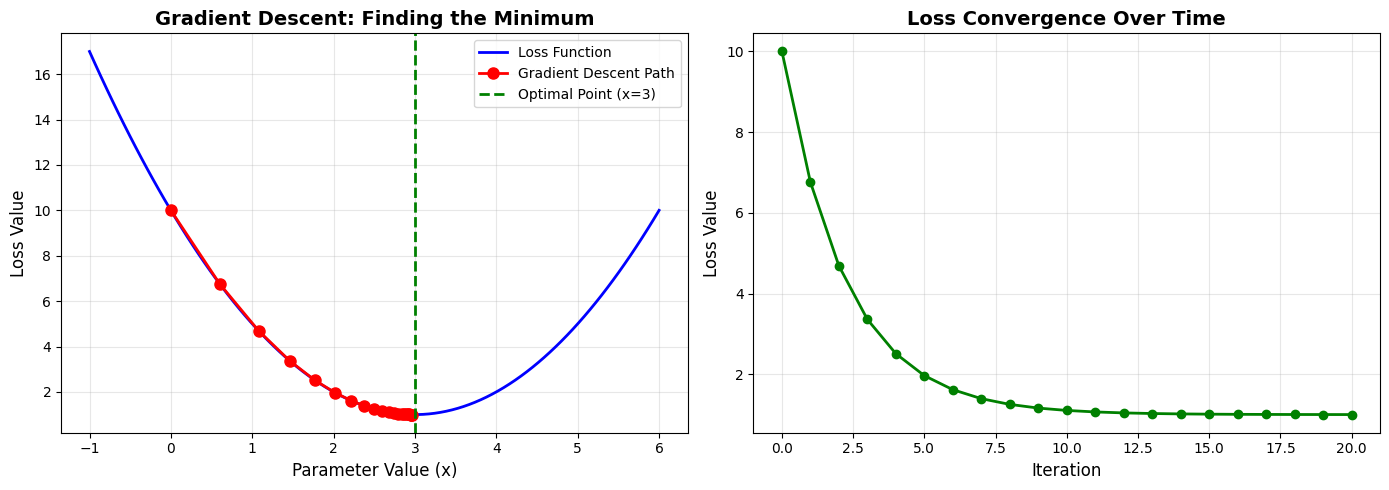

📊 Visual Analysis:
Left plot: Shows how gradient descent moves toward the minimum
Right plot: Shows how loss decreases over iterations

Key Observations:
✅ Started at x = 0.00, loss = 10.00
✅ Ended at x = 2.97, loss = 1.00
✅ Optimal is x = 3.0, loss = 1.00
✅ Converged in 20 iterations

💡 This is exactly how ML models learn!
 - They start with random parameters
 - Follow gradients to reduce loss
 - Converge to optimal values


In [3]:
# Interactive Example: Gradient Descent Visualization
# VISUAL: See gradient descent in action!

import numpy as np
import matplotlib.pyplot as plt

# Example: Visualizing gradient descent on a loss function
def loss_function(x):
 return (x - 3)**2 + 1

def loss_gradient(x):
 return 2 * (x - 3)

# Gradient descent
x = 0.0 # Starting point
learning_rate = 0.1
iterations = 20
path = [x]
loss_path = [loss_function(x)]

for i in range(iterations):
 grad = loss_gradient(x)
 x = x - learning_rate * grad
 path.append(x)
 loss_path.append(loss_function(x))
# Visualize the optimization process
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1: Loss function with gradient descent path
x_range = np.linspace(-1, 6, 100)
y_range = [loss_function(x) for x in x_range]

ax1.plot(x_range, y_range, 'b-', linewidth=2, label='Loss Function')
ax1.plot(path, loss_path, 'ro-', linewidth=2, markersize=8, label='Gradient Descent Path')
ax1.axvline(x=3, color='g', linestyle='--', linewidth=2, label='Optimal Point (x=3)')
ax1.set_xlabel('Parameter Value (x)', fontsize=12)
ax1.set_ylabel('Loss Value', fontsize=12)
ax1.set_title('Gradient Descent: Finding the Minimum', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Convergence over iterations
ax2.plot(range(len(loss_path)), loss_path, 'g-o', linewidth=2, markersize=6)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Loss Value', fontsize=12)
ax2.set_title('Loss Convergence Over Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Visual Analysis:")
print("=" * 60)
print("Left plot: Shows how gradient descent moves toward the minimum")
print("Right plot: Shows how loss decreases over iterations")
print("\nKey Observations:")
print(f"✅ Started at x = {path[0]:.2f}, loss = {loss_path[0]:.2f}")
print(f"✅ Ended at x = {path[-1]:.2f}, loss = {loss_path[-1]:.2f}")
print(f"✅ Optimal is x = 3.0, loss = {loss_function(3):.2f}")
print(f"✅ Converged in {iterations} iterations")
print("\n💡 This is exactly how ML models learn!")
print(" - They start with random parameters")
print(" - Follow gradients to reduce loss")
print(" - Converge to optimal values")

### Best Practices

**Best Practices for Calculus in ML:**

- **Learning Rate**: Start with small values (0.01-0.1) and adjust based on convergence
- **Gradient Checking**: Verify gradients numerically when implementing from scratch
- **Normalization**: Normalize features to help gradient descent converge faster
- **Batch Processing**: Use mini-batches for large datasets to compute gradients efficiently
- **Momentum**: Consider using momentum to smooth gradient updates

---

# Part 3: AFTER

## Analyzing Results and Understanding Implications

### What Happens Next?

After understanding calculus fundamentals:

- **Optimization Ready**: You understand how ML models are trained through optimization
- **Backpropagation**: You're ready to understand how neural networks compute gradients
- **Hyperparameter Tuning**: You can tune learning rates and other optimization parameters
- **Next Module**: Optimization techniques build on these calculus concepts

### How This Connects to Machine Learning

- **Training Process**: All ML training uses gradient-based optimization
- **Neural Networks**: Backpropagation is the chain rule applied to neural networks
- **Loss Functions**: Understanding derivatives helps design better loss functions
- **Convergence**: Calculus helps diagnose and fix convergence issues


> 💡 **Key Insight**: Calculus is the engine of machine learning. Every time a model learns, it's using gradients to minimize loss. Understanding derivatives and gradients is essential for debugging training issues and designing better models.


In [4]:
# Example: Understanding the Results and Implications

import numpy as np


---

## ⚠️ Where this breaks

- **This demo converged because the function is convex.** `f(x) = (x−3)² + 1` has one minimum, one basin
  and a well-behaved slope everywhere, so gradient descent walked to 2.97 in 20 steps. A neural network's
  loss surface has none of those properties. Nothing printed here is evidence that gradient descent will
  work on your model — it is evidence that the *mechanism* is what the notebook says it is.
- **Gradients need a differentiable objective, and the things you care about usually are not.** Accuracy,
  AUC, "did the customer buy", the number of correctly ranked search results — all of these are step
  functions with derivative zero almost everywhere and undefined at the jumps. Every classifier you train
  minimises a *surrogate* (cross-entropy) and hopes the surrogate's minimum is near the one you wanted.
  That gap is where a model with excellent loss and poor business value comes from.
- **The learning rate of 0.1 was chosen for you.** Change it to 1.1 on this same function and the loop
  diverges — notebook 03 of this unit runs exactly that experiment. The assumption hiding inside "gradient
  descent converges" is that someone already found a step size that works.


---

## 💬 Discuss

1. Reverse-mode differentiation gets 60 million partial derivatives for about the cost of two forward
   passes; nudging parameters one at a time would take 15 hours per step. Both compute the same vector.
   What does that tell you about where progress in AI actually comes from — new mathematics, or new ways
   of arranging old mathematics?
2. The model you can differentiate is rarely the model you were asked for (loss, not accuracy; clicks, not
   satisfaction). Pick one system you have used this week and name the mismatch between what it optimises
   and what its users actually want.
3. This module's whole apparatus assumes the loss is a smooth function of the parameters. Name one decision
   in a real ML project that is *not* smooth in that way, and say how you would improve it instead.


### Common Pitfalls and How to Avoid Them

**Common Pitfalls and How to Avoid Them:**

1. **Learning Rate Too High**: Causes divergence or oscillation
   - Solution: Start with smaller learning rates and use learning rate schedules

2. **Vanishing/Exploding Gradients**: Common in deep networks
   - Solution: Use proper initialization, batch normalization, gradient clipping

3. **Local Minima**: Gradient descent may get stuck
   - Solution: Use momentum, different initialization, or stochastic methods

### Advanced Topics

**Advanced Topics for Further Learning:**

- **Automatic Differentiation**: Using libraries like PyTorch/TensorFlow for gradients
- **Second-Order Methods**: Newton's method, quasi-Newton methods
- **Constrained Optimization**: Lagrange multipliers for ML with constraints
- **Stochastic Gradient Descent**: Variants like Adam, RMSprop

---

# Summary

## Key Takeaways

## Key Takeaways

In this module, you've learned the mathematical tools that enable machine learning models to learn from data:

1. **Derivatives and Gradients**: You discovered that derivatives tell us the direction to minimize loss functions. A positive derivative means the function is increasing (move left), while negative means decreasing (move right). Gradients extend this to multiple dimensions - they're vectors pointing in the direction of steepest increase, and the negative gradient points toward the minimum we want to find.

2. **Gradient Descent**: You learned the fundamental optimization algorithm used in all ML training. Starting from random parameters, we iteratively move in the direction opposite to the gradient (steepest descent) with a learning rate controlling step size. This simple algorithm is the foundation of how neural networks learn.

3. **Chain Rule**: You understood how to compute derivatives of composite functions by multiplying derivatives through each layer. This is exactly what backpropagation does in neural networks - it uses the chain rule to compute gradients through all layers, allowing deep networks to learn.

4. **Multivariable Calculus**: You saw that ML models have many parameters (weights), so we need partial derivatives for each. The gradient vector contains all partial derivatives, giving us the direction to update all parameters simultaneously. This enables efficient training of complex models.

## 🔗 How This Connects to Other Modules

**What you learned here connects to:**

- **Module 01**: Used vectors/matrices to compute gradients (gradients are vectors!)
- **Module 03**: You learned HOW to compute gradients → Module 03 teaches HOW to USE them for optimization
- **Module 04**: Optimization techniques will help find optimal reduced dimensions
- **Module 05**: Statistical inference builds on the optimization concepts

> 💡 **Key Insight**: Module 02 gave you the tools (gradients). Module 03 will show you how to use these tools effectively!

## Next Steps

1. Complete the exercises in the `exercises/` folder
2. Review the solutions if needed
3. Move on to **Module 03: Optimization and Statistical Foundations for Machine Learning**
   - You'll learn advanced optimization techniques (Adam, SGD) that USE the gradients you learned here
   - **Connection**: Module 02 = "How to compute gradients" | Module 03 = "How to use gradients for training"

---

**Ready for exercises?** Navigate to the `exercises/` folder and start practicing!

## 📚 References

1. Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*, Ch. 5: Vector Calculus. Cambridge University Press. <https://mml-book.github.io/>
2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 4: Numerical Computation. MIT Press. <https://www.deeplearningbook.org/>
3. Baydin, A. G., Pearlmutter, B. A., Radul, A. A., & Siskind, J. M. (2018). *Automatic Differentiation in Machine Learning: A Survey*. Journal of Machine Learning Research, 18(153). <https://arxiv.org/abs/1502.05767>
4. Blondel, M., & Roulet, V. (2024). *The Elements of Differentiable Programming*. arXiv. <https://arxiv.org/abs/2403.14606> — the current book-length treatment of differentiation as the foundation of machine learning.
